In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib


In [9]:
data = pd.read_csv("A:\PlePrep\Projects\AQI Project\AQI DataSets.csv")
data.head()


<>:1: SyntaxWarning: "\P" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\P"? A raw string is also an option.
<>:1: SyntaxWarning: "\P" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\P"? A raw string is also an option.
C:\Users\tiwar\AppData\Local\Temp\ipykernel_2128\399444462.py:1: SyntaxWarning: "\P" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\P"? A raw string is also an option.
  data = pd.read_csv("A:\PlePrep\Projects\AQI Project\AQI DataSets.csv")


,country,state,city,station,last_update,latitude,longitude,pollutant_id,pollutant_min,pollutant_max,pollutant_avg
0,India,Andhra_Pradesh,Rajamahendravaram,"Anand Kala Kshetram, Rajamahendravaram - APPCB",18-11-2025 17:00,16.987287,81.736318,NH3,1.0,3.0,2.0
1,India,Andhra_Pradesh,Amaravati,"Secretariat, Amaravati - APPCB",18-11-2025 17:00,16.515083,80.518167,PM10,75.0,160.0,112.0
2,India,Andhra_Pradesh,Chittoor,"Gangineni Cheruvu, Chittoor - APPCB",18-11-2025 17:00,13.204880,79.097889,PM10,11.0,175.0,84.0
3,India,Andhra_Pradesh,Chittoor,"Gangineni Cheruvu, Chittoor - APPCB",18-11-2025 17:00,13.204880,79.097889,SO2,7.0,34.0,16.0
4,India,Andhra_Pradesh,Kadapa,"Yerramukkapalli, Kadapa - APPCB",18-11-2025 17:00,14.465052,78.824187,PM10,63.0,73.0,64.0


In [11]:


# Shape and columns
print("🔹 Dataset Shape:", data.shape)
print("\n🔹 Columns:")
print(data.columns)

# ---------------------------------------
# 3. CHECK NULL VALUES
# ---------------------------------------
print("\n🔹 NULL VALUES BEFORE CLEANING:")
print(data.isnull().sum())

# Remove null values
data = data.dropna()

print("\n🔹 NULL VALUES AFTER REMOVING:")
print(data.isnull().sum())

# ---------------------------------------
# 4. CHECK DUPLICATES
# ---------------------------------------
print("\n🔹 DUPLICATE ROWS:", data.duplicated().sum())

# Remove duplicates
data = data.drop_duplicates()

print("🔹 Duplicates Removed! Remaining:", data.duplicated().sum())

# Reset index
data = data.reset_index(drop=True)

# ---------------------------------------
# 5. DATA TYPES CHECK
# ---------------------------------------
print("\n🔹 DATA TYPES:")
print(data.dtypes)

# ---------------------------------------
# 6. BASIC ENCODING
# ---------------------------------------

# pollutant_id (string → number)
if data["pollutant_id"].dtype == 'object':
    data["pollutant_id"] = data["pollutant_id"].astype("category").cat.codes

# Optional encoding for location columns
for col in ["country", "state", "city", "station"]:
    if col in data.columns and data[col].dtype == 'object':
        data[col] = data[col].astype("category").cat.codes

print("\n🔹 Encoding Completed!")

# ---------------------------------------
# 7. OUTLIER REMOVAL (IQR METHOD)
# ---------------------------------------
print("\n🔹 OUTLIER REMOVAL STARTED...")

numeric_cols = ["pollutant_min", "pollutant_max", "pollutant_avg"]

for col in numeric_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    before = len(data)
    data = data[(data[col] >= lower) & (data[col] <= upper)]
    after = len(data)

    print(f"   ➤ {col}: Removed {before - after} outliers")

data = data.reset_index(drop=True)

# ---------------------------------------
# 8. FEATURE ENGINEERING
# ---------------------------------------
data["pollution_range"] = data["pollutant_max"] - data["pollutant_min"]
data["pollution_intensity"] = data["pollutant_min"] * data["pollutant_max"]
data["pollution_ratio"] = data["pollutant_max"] / (data["pollutant_min"] + 1)

print("\n🔹 Feature Engineering Completed!")

# ---------------------------------------
# 9. FINAL CLEAN DATA PREVIEW
# ---------------------------------------
print("\n🔹 FINAL CLEAN DATA (TOP 5 ROWS):")
print(data.head())

print("\n🎉 PREPROCESSING COMPLETED SUCCESSFULLY!")


🔹 Dataset Shape: (3332, 11)

🔹 Columns:
Index(['country', 'state', 'city', 'station', 'last_update', 'latitude',
       'longitude', 'pollutant_id', 'pollutant_min', 'pollutant_max',
       'pollutant_avg'],
      dtype='object')

🔹 NULL VALUES BEFORE CLEANING:
country            0
state              0
city               0
station            0
last_update        0
latitude           0
longitude          0
pollutant_id       0
pollutant_min    208
pollutant_max    208
pollutant_avg    208
dtype: int64

🔹 NULL VALUES AFTER REMOVING:
country          0
state            0
city             0
station          0
last_update      0
latitude         0
longitude        0
pollutant_id     0
pollutant_min    0
pollutant_max    0
pollutant_avg    0
dtype: int64

🔹 DUPLICATE ROWS: 0
🔹 Duplicates Removed! Remaining: 0

🔹 DATA TYPES:
country           object
state             object
city              object
station           object
last_update       object
latitude         float64
longitude        flo

Numeric Columns Used for Correlation:
Index(['latitude', 'longitude', 'pollutant_id', 'pollutant_min',
       'pollutant_max', 'pollutant_avg'],
      dtype='object')


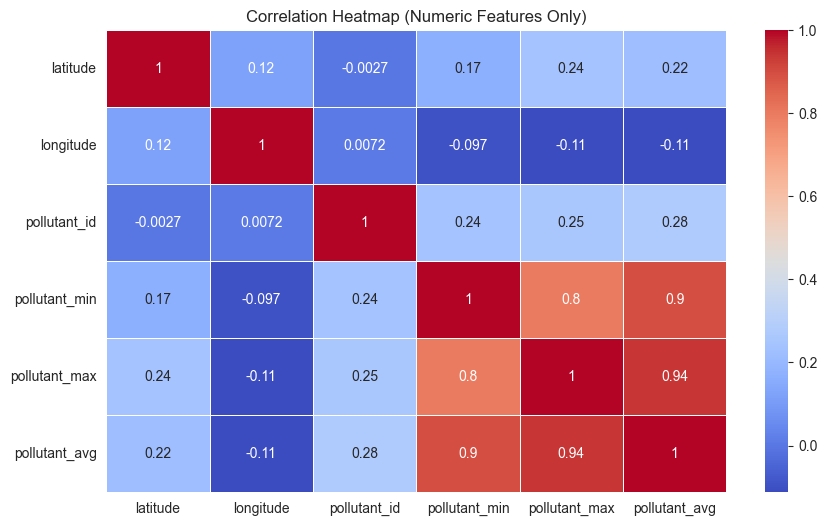

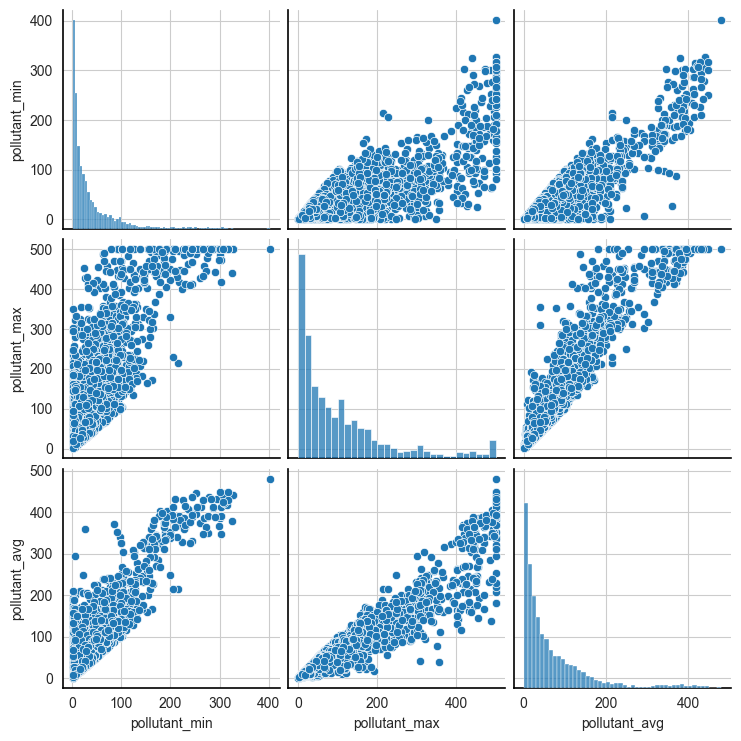

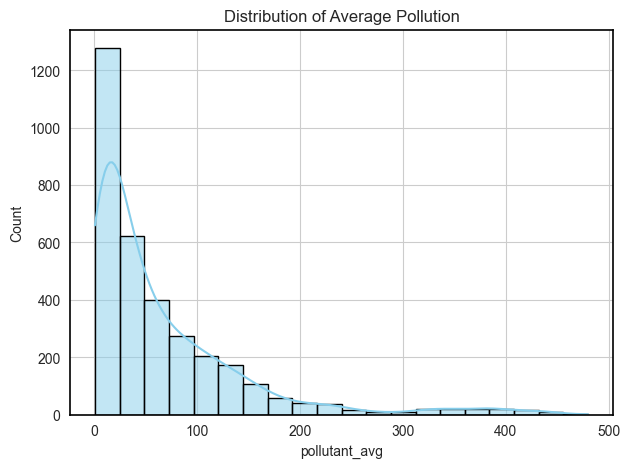

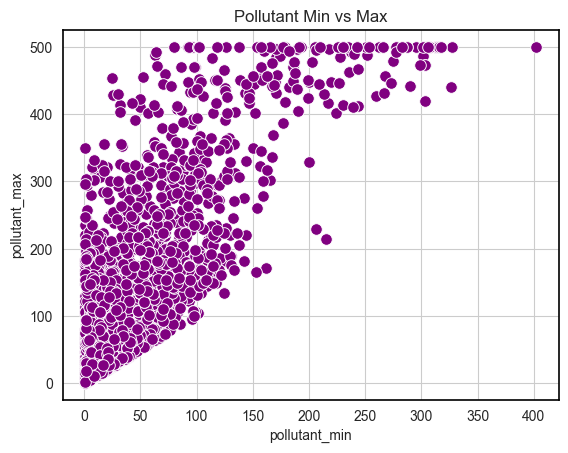

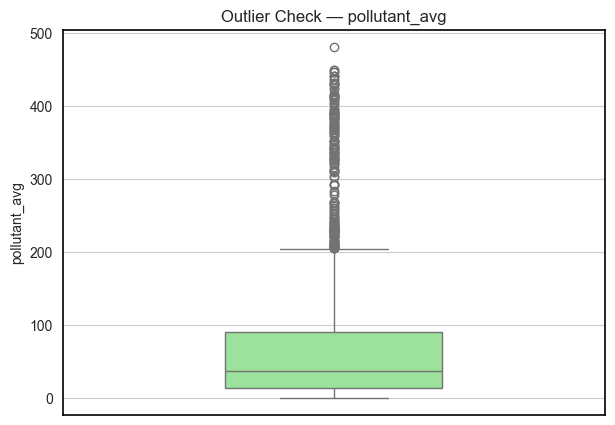

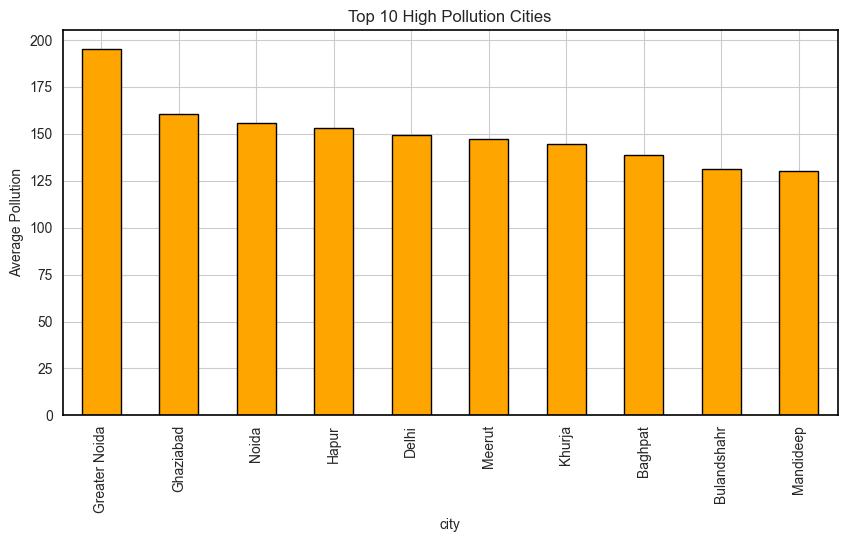

EDA Completed.


In [12]:


# Simple clean style for all plots
sns.set_style("whitegrid")
plt.rcParams["axes.edgecolor"] = "black"
plt.rcParams["axes.linewidth"] = 1.2

data = pd.read_csv("cleaned_pollution_data.csv")

# SELECT ONLY NUMERIC COLUMNS 
numeric_data = data.select_dtypes(include=['int64', 'float64'])

# CHECK if numeric columns exist 
print("Numeric Columns Used for Correlation:")
print(numeric_data.columns)

# CORRELATION HEATMAP ----
plt.figure(figsize=(10, 6))
sns.heatmap(
    numeric_data.corr(), 
    annot=True, 
    cmap="coolwarm",
    linewidths=0.5,
    linecolor="white"
)
plt.title("Correlation Heatmap (Numeric Features Only)")
plt.show()

# 2. Pairplot (Basic EDA)
sns.pairplot(
    data[["pollutant_min", "pollutant_max", "pollutant_avg"]],
    plot_kws={"edgecolor": "white"}
)
plt.show()

# 3. Histogram for Pollution Average
plt.figure(figsize=(7,5))
sns.histplot(
    data["pollutant_avg"],
    bins=20,
    kde=True,
    color="skyblue",
    edgecolor="black"
)
plt.title("Distribution of Average Pollution")
plt.show()

# 4. Scatter Plot (Min vs Max)
sns.scatterplot(
    x=data["pollutant_min"],
    y=data["pollutant_max"],
    color="purple",
    edgecolor="white",
    s=70
)
plt.title("Pollutant Min vs Max")
plt.show()

# 5. Boxplot — Outlier Detection
plt.figure(figsize=(7,5))
sns.boxplot(
    data["pollutant_avg"],
    color="lightgreen",
    width=0.4
)
plt.title("Outlier Check — pollutant_avg")
plt.show()

# 6. Pollution by Cities (Top 10)
top_cities = data.groupby("city")["pollutant_avg"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_cities.plot(
    kind="bar",
    color="orange",
    edgecolor="black"
)
plt.title("Top 10 High Pollution Cities")
plt.ylabel("Average Pollution")
plt.show()

print("EDA Completed.")


In [13]:
# -----------------------------------------
# 🔥 SIMPLE & CLEAN FEATURE ENGINEERING
# -----------------------------------------

print("\nStarting Feature Engineering...")

# 1️⃣ Pollution Range (max - min)
data["pollution_range"] = data["pollutant_max"] - data["pollutant_min"]

# 2️⃣ Pollution Midpoint ((max + min)/2)
data["pollution_mid"] = (data["pollutant_max"] + data["pollutant_min"]) / 2

# 3️⃣ Pollution Ratio (max/min)
data["pollution_ratio"] = data["pollutant_max"] / (data["pollutant_min"] + 1)

# 4️⃣ Pollution Intensity (min * max)
data["pollution_intensity"] = data["pollutant_min"] * data["pollutant_max"]

# 5️⃣ Geographical Combined Feature
data["geo_factor"] = data["latitude"] + data["longitude"]

# 6️⃣ Pollutant Category Weight (already encoded id)
data["pollutant_weight"] = data["pollutant_id"] * 1.0

print("Feature Engineering Completed!\n")
print(data.head())



Starting Feature Engineering...
Feature Engineering Completed!

  country           state               city  \
0   India  Andhra_Pradesh  Rajamahendravaram   
1   India  Andhra_Pradesh          Amaravati   
2   India  Andhra_Pradesh           Chittoor   
3   India  Andhra_Pradesh           Chittoor   
4   India  Andhra_Pradesh             Kadapa   

                                          station          last_update  \
0  Anand Kala Kshetram, Rajamahendravaram - APPCB  2025-11-18 17:00:00   
1                  Secretariat, Amaravati - APPCB  2025-11-18 17:00:00   
2             Gangineni Cheruvu, Chittoor - APPCB  2025-11-18 17:00:00   
3             Gangineni Cheruvu, Chittoor - APPCB  2025-11-18 17:00:00   
4                 Yerramukkapalli, Kadapa - APPCB  2025-11-18 17:00:00   

    latitude  longitude  pollutant_id  pollutant_min  pollutant_max  \
0  16.987287  81.736318             1            1.0            3.0   
1  16.515083  80.518167             4           75.0       

In [14]:
# -----------------------------------------
# 🔥 MACHINE LEARNING MODELS (Simple & Useful)
# -----------------------------------------

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("\nML Model Building Started...\n")

# 1️⃣ Select Features & Target
X = data[[
    "pollutant_min",
    "pollutant_max",
    "pollution_range",
    "pollution_mid",
    "pollution_ratio",
    "pollution_intensity",
    "geo_factor",
    "pollutant_weight"
]]

y = data["pollutant_avg"]

# 2️⃣ Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Data Splitting Done!")


# FUNCTION: For evaluating any model
def evaluate_model(name, model):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = mse ** 0.5
    r2 = r2_score(y_test, y_pred)

    print(f"\n📌 Results for: {name}")
    print("MAE :", mae)
    print("MSE :", mse)
    print("RMSE:", rmse)
    print("R²  :", r2)

    return model


# 3️⃣ Train & Evaluate 3 Models

# Linear Regression
lr_model = evaluate_model("Linear Regression", LinearRegression())

# Decision Tree
dt_model = evaluate_model("Decision Tree Regressor", DecisionTreeRegressor(random_state=42))

# Random Forest
rf_model = evaluate_model("Random Forest Regressor", RandomForestRegressor(n_estimators=100, random_state=42))


# 4️⃣ Save Best Model (Random Forest recommended)
import joblib
joblib.dump(rf_model, "pollution_model.pkl")

print("\nBest Model Saved as pollution_model.pkl")



ML Model Building Started...

Data Splitting Done!

📌 Results for: Linear Regression
MAE : 11.094844595660646
MSE : 342.6523726477067
RMSE: 18.51087174197117
R²  : 0.9505119031948657

📌 Results for: Decision Tree Regressor
MAE : 10.997001499250375
MSE : 417.08995502248877
RMSE: 20.422780296093105
R²  : 0.9397611406828816

📌 Results for: Random Forest Regressor
MAE : 8.269985007496253
MSE : 253.91654392803596
RMSE: 15.934758985564732
R²  : 0.9633277119628902

Best Model Saved as pollution_model.pkl
